In [1]:
#1: bussiness understanding
import pandas as pd 
df = pd.read_csv("titanic-dataset.csv")
#2: dataset understanding
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [4]:
#3: EDA
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
df["Age"].skew()

np.float64(0.38910778230082704)

In [6]:
df["Fare"].skew()

np.float64(4.787316519674893)

In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

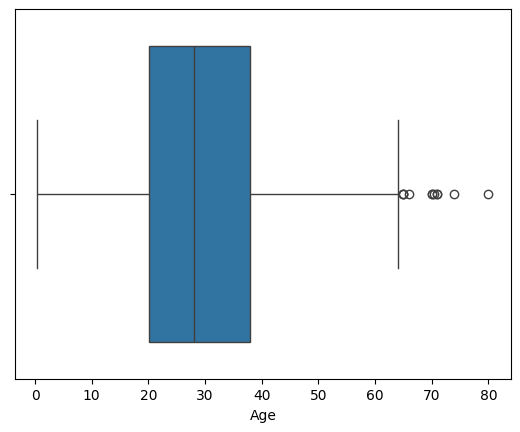

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.boxplot(x=df["Age"])
plt.show()

In [9]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
#Dataset Cleaning
df["Embarked"]=df["Embarked"].fillna("S")

In [12]:
df["Age"]=df["Age"].fillna(df["Age"].mean())

In [13]:
df.drop("Cabin",axis =1, inplace = True)

In [14]:
df.shape

(891, 11)

In [15]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [16]:
df.drop(["PassengerId","Name", "Ticket"], axis=1, inplace=True)

In [17]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [18]:
df.shape

(891, 8)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 55.8 KB


In [20]:
from  sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
#here we are using label encoder because we ahve only two values in sex
df["Sex"] = le.fit_transform(df["Sex"])

In [21]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,1,22.0,1,0,7.2500,S
1,1,1,0,38.0,1,0,71.2833,C
2,1,3,0,26.0,0,0,7.9250,S
3,1,1,0,35.0,1,0,53.1000,S
4,0,3,1,35.0,0,0,8.0500,S


In [22]:
df["Embarked"].unique()

<StringArray>
['S', 'C', 'Q']
Length: 3, dtype: str

In [23]:
embarked_encoded =pd.get_dummies(df["Embarked"], dtype=int)
embarked_encoded.head()
#one hot encoding

,C,Q,S
0,0,0,1
1,1,0,0
2,0,0,1
3,0,0,1
4,0,0,1


In [24]:
#now to add this colum permanently to the dataset
df = pd.concat([df, embarked_encoded], axis=1)
df.head()
#now we have got total 9 features in our dataset

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,C,Q,S
0,0,3,1,22.0,1,0,7.2500,S,0,0,1
1,1,1,0,38.0,1,0,71.2833,C,1,0,0
2,1,3,0,26.0,0,0,7.9250,S,0,0,1
3,1,1,0,35.0,1,0,53.1000,S,0,0,1
4,0,3,1,35.0,0,0,8.0500,S,0,0,1


In [25]:
#now let us remove the Embarked column feature name as it is not useful cause alraedy we have cqs which determines the value
df.drop("Embarked", axis=1, inplace=True)

In [26]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S
0,0,3,1,22.0,1,0,7.2500,0,0,1
1,1,1,0,38.0,1,0,71.2833,1,0,0
2,1,3,0,26.0,0,0,7.9250,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,0,1
4,0,3,1,35.0,0,0,8.0500,0,0,1


In [27]:
#feature-target split
x = df.drop("Survived", axis =1)
y = df["Survived"]
#why we do drop survived from x and why not from ybecause model learns full and prtedicts correctly but what is rthe usge of it 
# this is called data lekage

In [28]:
#Now Train-test split 
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)
#here 0.2 = 20% for testing and 80% for training
# random_state = 42 is used to get the same random split every time we run the code

In [29]:
x_train.shape

(712, 9)

In [30]:
x_test.shape

(179, 9)

In [31]:
y_train.shape

(712,)

In [32]:
y_test.shape

(179,)

In [33]:
#model selection
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(x_train,y_train)
#this is the actual step where model learns from the data and finds the pattern in the data and then it will use that pattern to predict the target variable for new data
y_pred = model.predict(x_test)
# model predicts the target variable for the test data and we will compare it with the actual target variable to see how well the model is performing

c:\ML_PROJECTS\SUPERVISED_LEARNING\CLASSIFICATION\titanic_dataset\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [34]:
#model evaluation
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
accuracy_score(y_test, y_pred)
#here 0.8 means 80% correct model predictions and 20% wrong predictions
#to check y = test = 179 and in that 80% = 144 and remaining 35 are wrong predictions
#then 20% of 179 = 35.8 which is approximately 36 wrong predictions and 144 correct predictions
#

0.8044692737430168

In [35]:
#noe accuracy is not the only metric to evaluate the model performance we can also use confusion matrix and classification report to evaluate the model performance in more detail  
confusion_matrix(y_test, y_pred)

array([[90, 15],
       [20, 54]])

In [36]:
y_test.value_counts()

Survived
0    105
1     74
Name: count, dtype: int64

In [37]:
y_test.head(5)

709    1
439    0
840    0
720    1
39     1
Name: Survived, dtype: int64

In [38]:
y_pred[:5]

array([0, 0, 0, 1, 1])

In [39]:
y_test.head(10)

709    1
439    0
840    0
720    1
39     1
290    1
300    1
333    0
208    1
136    1
Name: Survived, dtype: int64

In [40]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



In [41]:
# 0.82 means 82% that tells us 82% died as 0 indicates not survived like that for all 
#this step is model interpretation
pd.DataFrame({"feature": x.columns, "Weight": model.coef_[0]})
#this one is used for finding the importance of features as well as weights.

,feature,Weight
0,Pclass,-0.865286
1,Sex,-2.575927
2,Age,-0.028768
3,SibSp,-0.255592
4,Parch,-0.119241
5,Fare,0.002552
6,C,1.346475
7,Q,0.719009
8,S,0.724415


In [42]:
#Feature Scaling:
#feature scaling is used to bring all features to a similar values
#method to bring all in similar values we use STANDARD SCALER
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)

In [43]:
x_test = scaler.transform(x_test)
#by this step all features become centered around 0 and have similar spread
#why we are converting into small values beacuse for logistic regression
#faster learning
#better optimization
#more meaningful weights


In [44]:
x_train[:5]
#below output values are called z-scores
#positive means exactly above average
#negative means exactly below average

array([[-1.61413602,  0.7243102 ,  1.22920747, -0.47072241, -0.47934164,
        -0.07868358, -0.46146201, -0.30335547,  0.59248936],
       [-0.40055118,  0.7243102 , -0.50350514, -0.47072241, -0.47934164,
        -0.37714494, -0.46146201, -0.30335547,  0.59248936],
       [ 0.81303367,  0.7243102 ,  0.18957991, -0.47072241, -0.47934164,
        -0.47486697, -0.46146201, -0.30335547,  0.59248936],
       [ 0.81303367,  0.7243102 , -0.27247679,  0.37992316, -0.47934164,
        -0.47623026, -0.46146201, -0.30335547,  0.59248936],
       [ 0.81303367, -1.38062393, -1.81266577,  2.93185988,  2.04874166,
        -0.02524937, -0.46146201, -0.30335547,  0.59248936]])

In [45]:
pd.DataFrame(x_train,columns=x.columns).head()

,Pclass,Sex,Age,SibSp,Parch,Fare,C,Q,S
0,-1.614136,0.724310,1.229207,-0.470722,-0.479342,-0.078684,-0.461462,-0.303355,0.592489
1,-0.400551,0.724310,-0.503505,-0.470722,-0.479342,-0.377145,-0.461462,-0.303355,0.592489
2,0.813034,0.724310,0.189580,-0.470722,-0.479342,-0.474867,-0.461462,-0.303355,0.592489
3,0.813034,0.724310,-0.272477,0.379923,-0.479342,-0.476230,-0.461462,-0.303355,0.592489
4,0.813034,-1.380624,-1.812666,2.931860,2.048742,-0.025249,-0.461462,-0.303355,0.592489


In [46]:
model = LogisticRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
#here why im training model again because previous values where 1,5,10 like that but now after scaling all values look similar
#so now we are using those values and taring model on that 
#by this model could easily genlarize,fater learning, easy optimization, most important this is working on scaled data

In [47]:
from sklearn.metrics import top_k_accuracy_score
accuracy_score(y_test, y_pred)

0.8100558659217877

In [48]:
confusion_matrix(y_test, y_pred)

array([[90, 15],
       [19, 55]])

In [49]:
#classification report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [50]:
#above all steps are called model improvement 
#CROSS VALIDATION
from sklearn.model_selection import cross_val_score
scores = cross_val_score(LogisticRegression(),x_train,y_train,cv=5)
scores
#this step checks did model get luckly on one train test split
# or is the model consistently good
#cv= 5 means 5 folds validation

array([0.82517483, 0.8041958 , 0.78873239, 0.73943662, 0.79577465])

In [51]:
scores.mean()

np.float64(0.7906628582684921)

In [52]:
scores.std()

np.float64(0.028383802018759997)

In [53]:
from sklearn.model_selection import GridSearchCV
params = {"C":[0.01, 0.1, 1, 10],
        "max_iter":[100,500,1000]}
grid = GridSearchCV(LogisticRegression(),params,cv=5)
grid.fit(x_train,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegression()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...], 'max_iter': [100, 500, ...]}"
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during f

In [54]:
grid.best_params_

{'C': 0.01, 'max_iter': 100}

In [55]:
grid.best_score_

np.float64(0.8005318625036935)

In [57]:
final_model = LogisticRegression(C= 0.01,max_iter = 100)

In [58]:
final_model.fit(x_train,y_train)

,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.01
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default so

In [59]:
final_pred = final_model.predict(x_test)

In [ ]:
accuracy_score(y_test,final_pred)
#here why we are traning again because 
# after grid it trained on many temporarary models after finding the best parameter we need ti build our own final model
#this 0.79 is performed accuracy totally on unseen data 
#where as that 80% is on seen data that is on x_train(known data)
#now here by this we could conform model generalizes well on unseen data

0.7988826815642458

In [61]:
import joblib
joblib.dump(final_model, "titanic_model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [62]:
import joblib

loaded_model = joblib.load("titanic_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

In [ ]:
#creating new passenger
new_passenger = [[
    3,    #Pclass
    1,    #Sex
    22,   #Age
    1,    #Sibsp
    0,    #Parch
    7.25, #Fare
    0,    #C
    0,    #Q
    1,    #S
#]]

In [ ]:
#SCALING NEW PASSENGER :
new_passenger_scaled = loaded_scaler.transform(new_passenger)

c:\ML_PROJECTS\SUPERVISED_LEARNING\CLASSIFICATION\titanic_dataset\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [ ]:
prediction = loaded_model.predict(new_passenger_scaled)

prediction
#here array 0 means not survived

array([0])